In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

In [3]:
fake_df = pd.read_csv("Fake.csv")
true_df = pd.read_csv("True.csv")

In [4]:
fake_df.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [5]:
true_df.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [6]:
print("Fake News Shape :", fake_df.shape)
print("True News Shape :", true_df.shape)

Fake News Shape : (23481, 4)
True News Shape : (21417, 4)


In [7]:
print(fake_df.columns)

print(true_df.columns)

Index(['title', 'text', 'subject', 'date'], dtype='object')
Index(['title', 'text', 'subject', 'date'], dtype='object')


In [8]:
fake_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23481 entries, 0 to 23480
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    23481 non-null  object
 1   text     23481 non-null  object
 2   subject  23481 non-null  object
 3   date     23481 non-null  object
dtypes: object(4)
memory usage: 733.9+ KB


In [9]:
true_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21417 entries, 0 to 21416
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    21417 non-null  object
 1   text     21417 non-null  object
 2   subject  21417 non-null  object
 3   date     21417 non-null  object
dtypes: object(4)
memory usage: 669.4+ KB


In [10]:
print(fake_df.isnull().sum())

title      0
text       0
subject    0
date       0
dtype: int64


In [11]:
print(true_df.isnull().sum())

title      0
text       0
subject    0
date       0
dtype: int64


In [35]:
print("Fake:", fake_df.duplicated().sum())

print("True:", true_df.duplicated().sum())

Fake: 3
True: 206


In [13]:
fake_df = fake_df.drop_duplicates()

true_df = true_df.drop_duplicates()

In [14]:
print("Fake:", fake_df.duplicated().sum())
print("True:", true_df.duplicated().sum())

Fake: 0
True: 0


In [15]:
fake_df["label"] = 1

true_df["label"] = 0

In [16]:
df = pd.concat([fake_df, true_df], ignore_index=True)

In [17]:
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

In [18]:
print(df.shape)

(44689, 5)


In [19]:
df["label"].value_counts()

label
1    23478
0    21211
Name: count, dtype: int64

In [20]:
df.isnull().sum()

title      0
text       0
subject    0
date       0
label      0
dtype: int64

In [21]:
df.to_csv("cleaned_fake_news.csv", index=False)

In [22]:
df["label"].value_counts()

label
1    23478
0    21211
Name: count, dtype: int64

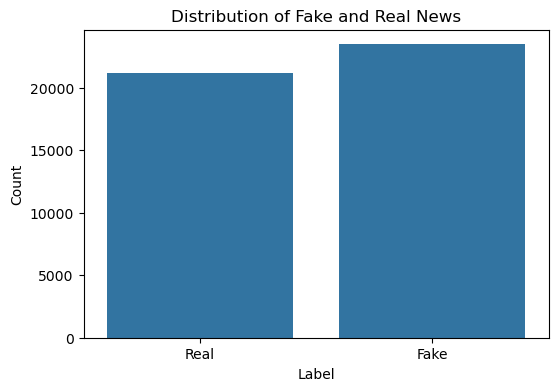

In [23]:
plt.figure(figsize=(6,4))

sns.countplot(x="label", data=df)

plt.title("Distribution of Fake and Real News")
plt.xlabel("Label")
plt.ylabel("Count")

plt.xticks([0,1],["Real","Fake"])

plt.show()

In [24]:
df["subject"].value_counts()

subject
politicsNews       11220
worldnews           9991
News                9050
politics            6838
left-news           4459
Government News     1570
US_News              783
Middle-east          778
Name: count, dtype: int64

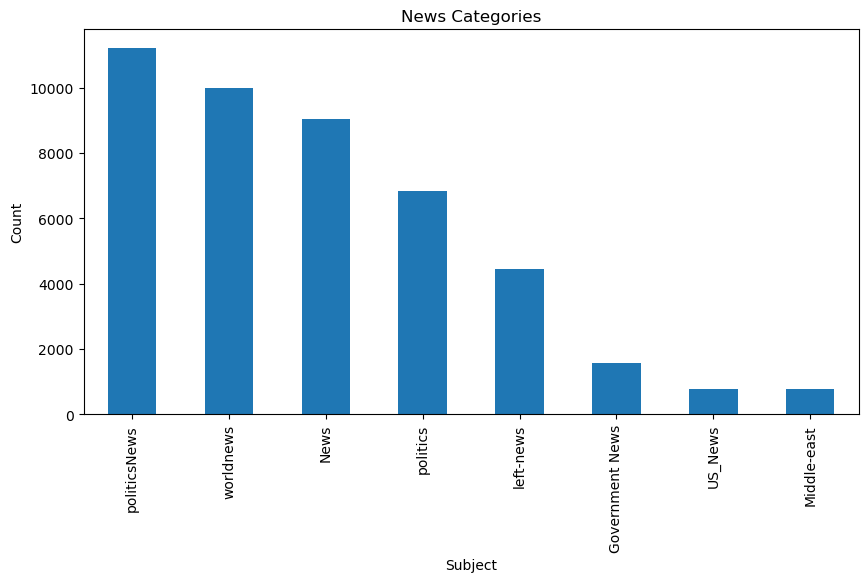

In [25]:
plt.figure(figsize=(10,5))

df["subject"].value_counts().plot(kind="bar")

plt.title("News Categories")

plt.xlabel("Subject")

plt.ylabel("Count")

plt.show()

In [26]:
df["article_length"] = df["text"].astype(str).apply(len)

In [27]:
df["article_length"].describe()

count    44689.000000
mean      2467.098682
std       2173.612347
min          1.000000
25%       1232.000000
50%       2185.000000
75%       3101.000000
max      51794.000000
Name: article_length, dtype: float64

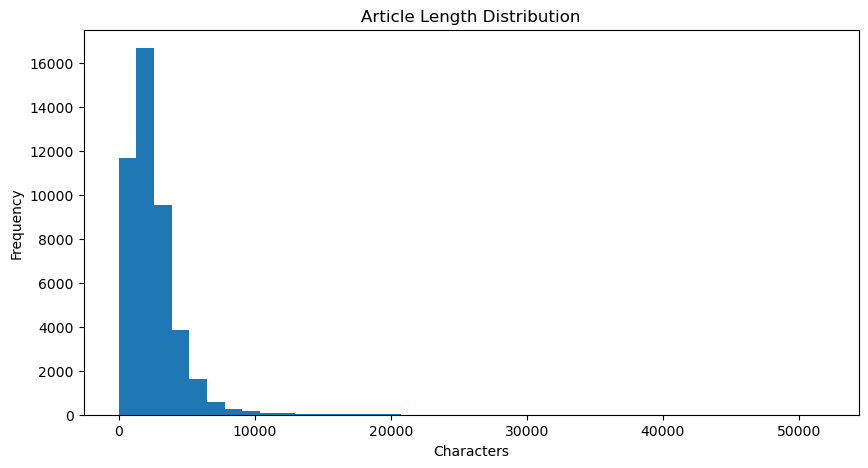

In [28]:
plt.figure(figsize=(10,5))

plt.hist(df["article_length"], bins=40)

plt.title("Article Length Distribution")

plt.xlabel("Characters")

plt.ylabel("Frequency")

plt.show()

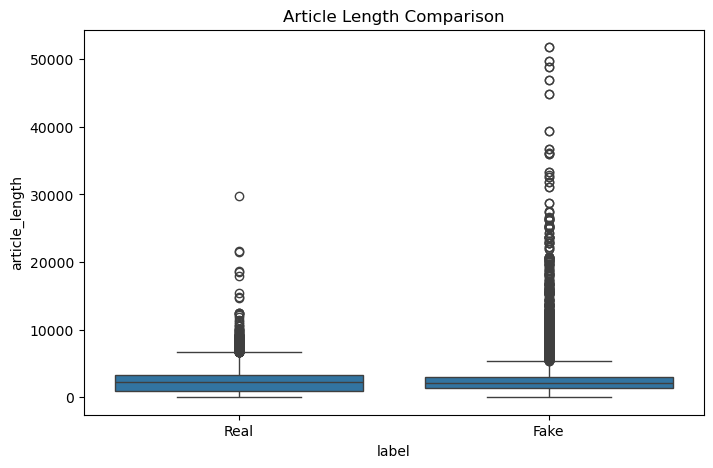

In [29]:
plt.figure(figsize=(8,5))

sns.boxplot(x="label",
            y="article_length",
            data=df)

plt.xticks([0,1],["Real","Fake"])

plt.title("Article Length Comparison")

plt.show()

In [30]:
df["date"] = pd.to_datetime(df["date"], errors="coerce")

In [31]:
df["date"] = pd.to_datetime(df["date"], errors="coerce")

print(df["date"].min())
print(df["date"].max())

2015-03-31 00:00:00
2017-12-31 00:00:00


In [32]:
df["year"] = df["date"].dt.year

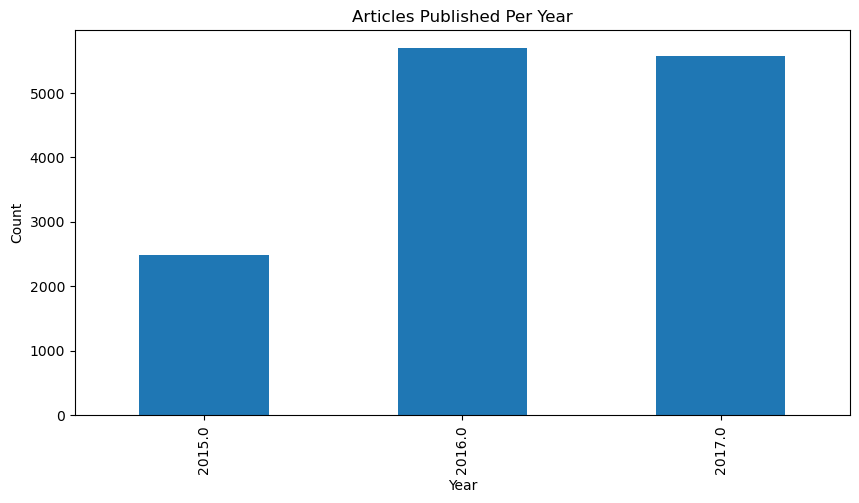

In [33]:
plt.figure(figsize=(10,5))

df["year"].value_counts().sort_index().plot(kind="bar")

plt.title("Articles Published Per Year")
plt.xlabel("Year")
plt.ylabel("Count")

plt.show()

In [34]:
df.to_csv("processed_fake_news.csv", index=False)

In [35]:
import re
import string
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [36]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\MANASA.M.SWAMY\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\MANASA.M.SWAMY\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\MANASA.M.SWAMY\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [37]:
df["content"] = df["title"] + " " + df["text"]

In [38]:
stop_words = set(stopwords.words("english"))

lemmatizer = WordNetLemmatizer()

In [39]:
def clean_text(text):

    text = text.lower()

    text = re.sub(r"http\S+", "", text)

    text = re.sub(r"www\S+", "", text)

    text = re.sub(r"<.*?>", "", text)

    text = re.sub(r"\d+", "", text)

    text = text.translate(str.maketrans("", "", string.punctuation))

    words = text.split()

    words = [lemmatizer.lemmatize(word)
             for word in words
             if word not in stop_words]

    return " ".join(words)

In [40]:
df["clean_text"] = df["content"].apply(clean_text)

In [41]:
df[["content", "clean_text"]].head()

,content,clean_text
0,WOW! LEFTIST LIBRARIAN REJECTS Shipment Of Chi...,wow leftist librarian reject shipment children...
1,Kenya opposition leader calls for calm in slum...,kenya opposition leader call calm slum hit dea...
2,Egypt rejects U.S. decision to move its embass...,egypt reject u decision move embassy jerusalem...
3,(AUDIO)NATION OF ISLAM LEADER FARRAKHAN: “WE W...,audionation islam leader farrakhan “we kill al...
4,Trump Rally Nearly Turns Into A Full-Blown Ra...,trump rally nearly turn fullblown race war st ...


In [42]:
df.to_csv("final_processed_news.csv", index=False)

In [43]:
X = df["clean_text"]

y = df["label"]

In [44]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [45]:
print("Training Samples :", X_train.shape)

print("Testing Samples :", X_test.shape)

Training Samples : (35751,)
Testing Samples : (8938,)


In [46]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=30000,
    ngram_range=(1,2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

In [47]:
X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

In [48]:
print(X_train_tfidf.shape)

print(X_test_tfidf.shape)

(35751, 30000)
(8938, 30000)


In [49]:
import joblib

joblib.dump(tfidf, "tfidf_vectorizer.pkl")

['tfidf_vectorizer.pkl']

In [50]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.linear_model import PassiveAggressiveClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

In [51]:
models = {

    "Logistic Regression":
    LogisticRegression(max_iter=1000),

    "Naive Bayes":
    MultinomialNB(),

    "Linear SVM":
    LinearSVC(max_iter=10000),

    "Passive Aggressive":
    PassiveAggressiveClassifier(max_iter=1000,
                                random_state=42),

    "Random Forest":
    RandomForestClassifier(
        n_estimators=300,
        random_state=42
    )

}

In [52]:
results = []

for name, model in models.items():

    model.fit(X_train_tfidf, y_train)

    prediction = model.predict(X_test_tfidf)

    accuracy = accuracy_score(y_test, prediction)

    precision = precision_score(y_test, prediction)

    recall = recall_score(y_test, prediction)

    f1 = f1_score(y_test, prediction)

    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1
    ])

    print(name, "Completed")

Logistic Regression Completed
Naive Bayes Completed
Linear SVM Completed
Passive Aggressive Completed
Random Forest Completed


In [53]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

results_df.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
2,Linear SVM,0.998546,0.999147,0.998083,0.998615
3,Passive Aggressive,0.998210,0.999147,0.997445,0.998295
4,Random Forest,0.996532,0.997866,0.995528,0.996695
0,Logistic Regression,0.994070,0.996365,0.992334,0.994345
1,Naive Bayes,0.963527,0.969085,0.961244,0.965149


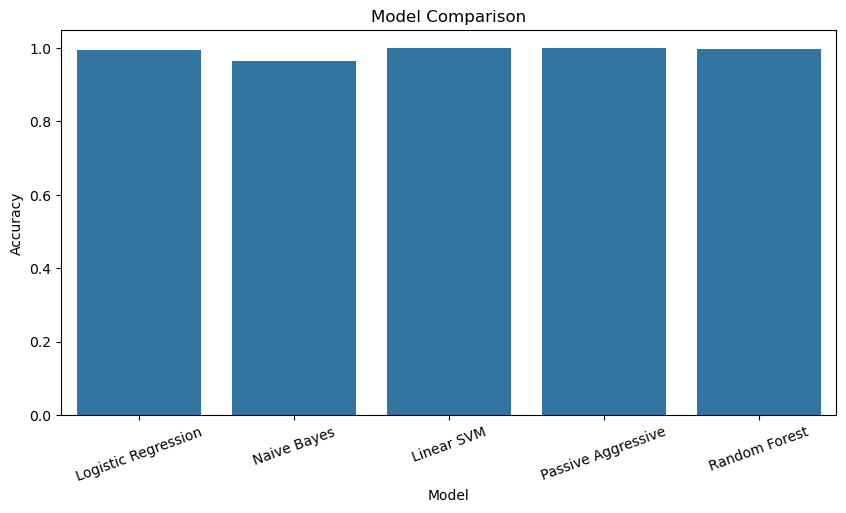

In [54]:
plt.figure(figsize=(10,5))

sns.barplot(
    x="Model",
    y="Accuracy",
    data=results_df
)

plt.xticks(rotation=20)

plt.title("Model Comparison")

plt.show()

In [55]:
results_df.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score
2,Linear SVM,0.998546,0.999147,0.998083,0.998615
3,Passive Aggressive,0.998210,0.999147,0.997445,0.998295
4,Random Forest,0.996532,0.997866,0.995528,0.996695
0,Logistic Regression,0.994070,0.996365,0.992334,0.994345
1,Naive Bayes,0.963527,0.969085,0.961244,0.965149


In [56]:
from sklearn.svm import LinearSVC

best_model = LinearSVC(max_iter=10000)

best_model.fit(X_train_tfidf, y_train)

LinearSVC(max_iter=10000)

In [57]:
import joblib

joblib.dump(best_model, "fake_news_model.pkl")

['fake_news_model.pkl']

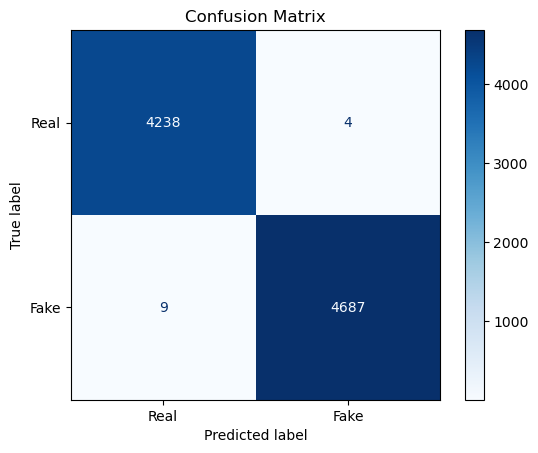

In [58]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

prediction = best_model.predict(X_test_tfidf)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    prediction,
    display_labels=["Real", "Fake"],
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.show()

In [59]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    prediction,
    target_names=["Real", "Fake"]
))

              precision    recall  f1-score   support

        Real       1.00      1.00      1.00      4242
        Fake       1.00      1.00      1.00      4696

    accuracy                           1.00      8938
   macro avg       1.00      1.00      1.00      8938
weighted avg       1.00      1.00      1.00      8938



In [60]:
results_df.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score
2,Linear SVM,0.998546,0.999147,0.998083,0.998615
3,Passive Aggressive,0.998210,0.999147,0.997445,0.998295
4,Random Forest,0.996532,0.997866,0.995528,0.996695
0,Logistic Regression,0.994070,0.996365,0.992334,0.994345
1,Naive Bayes,0.963527,0.969085,0.961244,0.965149


In [61]:
best_accuracy = results_df["Accuracy"].max()
print(f"Best Model Accuracy: {best_accuracy*100:.2f}%")

Best Model Accuracy: 99.85%


In [62]:
best_model = LinearSVC(max_iter=10000)
best_model.fit(X_train_tfidf, y_train)

LinearSVC(max_iter=10000)

In [63]:
from sklearn.metrics import accuracy_score

prediction = best_model.predict(X_test_tfidf)

accuracy = accuracy_score(y_test, prediction)

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy*100)

Accuracy: 0.9985455359140747
Accuracy (%): 99.85455359140747
